# Aufgabe 1 - Akku-Abenteuer: Tobi's Optimale Routenplanung

Den Code immer nachvollziehbar kommentieren! Bitte beachtet, dass das Notebook von Anfang bis Ende ohne Fehler durchlaufen muss und dass die requirements.txt Datei aktualisiert wird. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import deque
import heapq

## Teilaufgabe a): lageplan.png laden und verarbeiten

(21, 21)
[0 1 2 3 4 5]


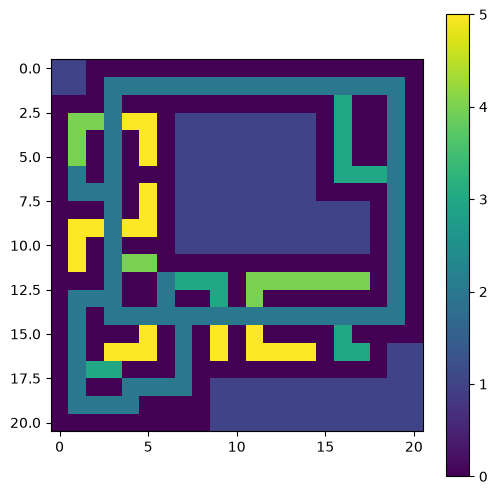

In [ ]:
#lade Lageplan als Numpy-Array mit RGB
img = np.array(Image.open("lageplan.png").convert("RGB"))

#erzeuge 21x21-Matrix
matrix = np.zeros((21, 21), dtype=int)

#ordne Farben einem Raumtyp zu
def classify(rgb):

    r, g, b = rgb

    if r < 50 and g < 50 and b < 50:
        return 0

    if r > 200 and g > 200 and b > 200:
        return 1

    if b > 200:
        return 3

    if g > 200 and r < 100:
        return 4

    if r > 200 and g > 200:
        return 5

    return 2
        
    
for y in range(21):
    for x in range(21):
        rgb = img[y*20+10, x*20+10]
        matrix[y, x] = classify(rgb)
        

print(matrix.shape)
print(np.unique(matrix))

plt.figure(figsize=(6,6))
plt.imshow(matrix)
plt.colorbar()
plt.show()



## Teilaufgabe b): Breitensuche

In [ ]:
# bestimme Nachbarn
def get_neighbors(pos):
    y, x = pos
    directions = [
        (-1,0), #oben
        (1,0), #unten
        (0,-1), #links
        (0,1) #rechts
    ]
    neighbors = []

    for dy, dx in directions:
        ny = y + dy
        nx = x + dx

        if 0 <= ny < 21 and 0 <= nx < 21:
            neighbors.append((ny, nx))
    return neighbors


#implementiere Breitensuche

def bfs(matrix, start, goal):

    queue = deque([start])
    visited = {start}
    parent = {start: None}
    while queue:
        current = queue.popleft()

        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = parent[current]
            return path[::-1]
        for neighbor in get_neighbors(current):
            y, x = neighbor
            
            #Wände und Draußen ausschließen
            if matrix[y, x] in [0,1]:
                continue

            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                queue.append(neighbor)
    return None
    
start = (17,3) #(y,x)
goal = (3,1) #(y,x)

path_bfs = bfs(matrix, start, goal)
print(matrix[17,3]) #Start
print(matrix[3,1]) #Ziel

print(np.argwhere(matrix == 3))
print(np.argwhere(matrix == 4))

print("Gefundener Pfad:")
print(path_bfs)

3
4
[[ 2 16]
 [ 3 16]
 [ 4 16]
 [ 5 16]
 [ 6 16]
 [ 6 17]
 [ 6 18]
 [12  7]
 [12  8]
 [12  9]
 [13  9]
 [15 16]
 [16 16]
 [16 17]
 [17  2]
 [17  3]]
[[ 3  1]
 [ 3  2]
 [ 4  1]
 [ 5  1]
 [11  4]
 [11  5]
 [12 11]
 [12 12]
 [12 13]
 [12 14]
 [12 15]
 [12 16]
 [12 17]
 [13 11]]
Gefundener Pfad:
[(17, 3), (16, 3), (16, 4), (16, 5), (15, 5), (14, 5), (14, 4), (14, 3), (13, 3), (12, 3), (11, 3), (10, 3), (9, 3), (8, 3), (7, 3), (6, 3), (5, 3), (4, 3), (3, 3), (3, 2), (3, 1)]


## Teilaufgabe c): A*-Algorithmus

A*-Pfad:
[(17, 3), (17, 2), (17, 1), (16, 1), (15, 1), (14, 1), (13, 1), (13, 2), (13, 3), (12, 3), (11, 3), (10, 3), (9, 3), (8, 3), (7, 3), (6, 3), (5, 3), (4, 3), (3, 3), (3, 2), (3, 1)]


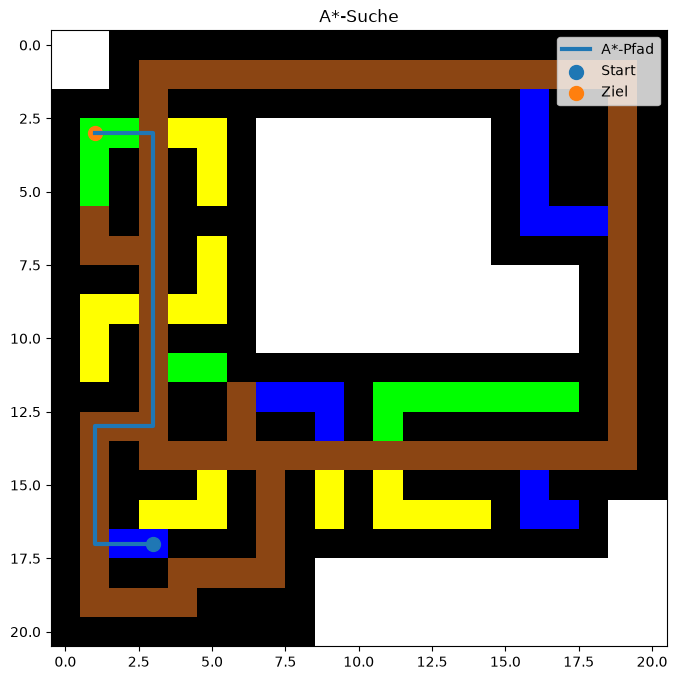

In [ ]:
def heuristic(a,b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

weights = {
    2: 2, #Flur
    3: 3, #Teeküche
    4: 4, #Professorenbüro
    5: 5, #Labor
    }

def a_star(matrix, start, goal):
    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {start: None}
    g_cost = {start: 0}

    while open_list:
        _, current = heapq.heappop(open_list)
        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1]
        for neighbor in get_neighbors(current):
            y, x = neighbor
            if matrix[y, x] in [0,1]:
                continue

            new_cost = g_cost[current] + weights[matrix[y,x]]

            if neighbor not in g_cost or new_cost < g_cost[neighbor]:
                g_cost[neighbor] = new_cost
                priority = new_cost + heuristic(neighbor, goal)

                heapq.heappush(
                    open_list, 
                    (priority, neighbor)
                )

                came_from[neighbor] = current
    return None
start = (17, 3)
goal = (3, 1)

path_astar = a_star(matrix, start, goal)

print("A*-Pfad:")
print(path_astar)


from matplotlib.colors import ListedColormap
cmap = ListedColormap([
    "black", #Wand (0)
    "white", #Draußen (1)
    "saddlebrown", #Flur (2)
    "blue", #Teeküche(3)
    "lime", #Professorenbüro (4)
    "yellow" #Labor (5)
])

plt.figure(figsize=(8,8))
plt.imshow(matrix, cmap=cmap)

x_coords = [p[1] for p in path_astar]
y_coords = [p[0] for p in path_astar]

plt.plot(x_coords, y_coords, linewidth=3, label="A*-Pfad")

plt.scatter(x_coords[0], y_coords[0], s=100, label="Start")
plt.scatter(x_coords[-1], y_coords[-1], s=100, label="Ziel")

plt.title("A*-Suche")
plt.legend()
plt.show()

## Teilaufgabe d): Greedy Best First Search-Algorithmus

In [ ]:
import heapq

def greedy_best_first_search(matrix, start, goal):

    open_list = []
    heapq.heappush(open_list, (heuristic(start, goal), start))

    visited = {start}
    parent = {start: None}

    while open_list:
        _, current = heapq.heappop(open_list)

        if current == goal:
            path = []

            while current is not None:
                path.append(current)
                current = parent[current]
            return path[::-1]

        for neighbor in get_neighbors(current):
            y, x = neighbor

            if matrix[y, x] in [0, 1]:
                continue

            if neighbor not in visited:
                visited.add(neighbor)
                priority = heuristic(neighbor, goal)

                heapq.heappush(
                    open_list,
                    (priority, neighbor)
                )

                parent[neighbor] = current

    return None

path_greedy = greedy_best_first_search(
    matrix,
    start,
    goal
)

print("Greedy-Pfad:")
print(path_greedy)

Greedy-Pfad:
[(17, 3), (17, 2), (17, 1), (16, 1), (15, 1), (14, 1), (13, 1), (13, 2), (13, 3), (12, 3), (11, 3), (10, 3), (9, 3), (8, 3), (7, 3), (6, 3), (5, 3), (4, 3), (3, 3), (3, 2), (3, 1)]


## Teilaufgabe e): Dusseliger Doktorand

A* ohne Kaffee:
[(17, 3), (17, 2), (17, 1), (16, 1), (15, 1), (14, 1), (13, 1), (13, 2), (13, 3), (12, 3), (11, 3), (10, 3), (9, 3), (8, 3), (7, 3), (6, 3), (5, 3), (4, 3), (3, 3), (3, 2), (3, 1)]

A* mit Kaffee:
[(17, 3), (16, 3), (16, 4), (16, 5), (15, 5), (14, 5), (14, 6), (14, 7), (14, 8), (14, 9), (14, 10), (14, 11), (14, 12), (14, 13), (14, 14), (14, 15), (14, 16), (14, 17), (14, 18), (14, 19), (13, 19), (12, 19), (11, 19), (10, 19), (9, 19), (8, 19), (7, 19), (6, 19), (5, 19), (4, 19), (3, 19), (2, 19), (1, 19), (1, 18), (1, 17), (1, 16), (1, 15), (1, 14), (1, 13), (1, 12), (1, 11), (1, 10), (1, 9), (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (2, 3), (3, 3), (3, 2), (3, 1)]

Pfadlänge ohne Kaffee: 21
Pfadlänge mit Kaffee: 53

Greedy Best First Search:
[(17, 3), (17, 2), (17, 1), (16, 1), (15, 1), (14, 1), (13, 1), (13, 2), (13, 3), (12, 3), (11, 3), (10, 3), (9, 3), (8, 3), (7, 3), (6, 3), (5, 3), (4, 3), (3, 3), (3, 2), (3, 1)]


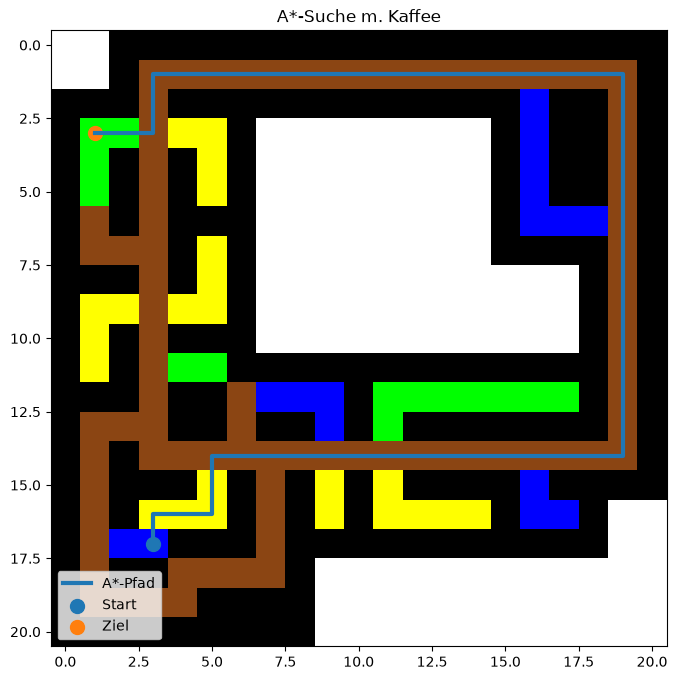

In [ ]:
def heuristic(a,b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

weights = {
    2: 2, #Flur
    3: 3, #Teeküche
    4: 4, #Professorenbüro
    5: 5, #Labor
}

cost_matrix = np.zeros((21, 21))

for y in range(21):
    for x in range(21):
        if matrix[y, x] == 2:
            cost_matrix[y, x] = 2

        elif matrix[y, x] == 3:
            cost_matrix[y, x] = 3

        elif matrix[y, x] == 4:
            cost_matrix[y, x] = 4

        elif matrix[y, x] == 5:
            cost_matrix[y, x] = 5

coffee_cost_matrix = cost_matrix.copy()

for y in range(3, 15):
    coffee_cost_matrix[y, 3] = 20

def a_star(matrix, cost_matrix, start, goal):
    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {start: None}
    g_cost = {start: 0}

    while open_list:
        _, current = heapq.heappop(open_list)
        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1]
        
        for neighbor in get_neighbors(current):
            y, x = neighbor
            if matrix[y, x] in [0,1]:
                continue

            new_cost = g_cost[current] + cost_matrix[y,x]

            if neighbor not in g_cost or new_cost < g_cost[neighbor]:
                g_cost[neighbor] = new_cost
                priority = new_cost + heuristic(neighbor, goal)

                heapq.heappush(
                    open_list, 
                    (priority, neighbor)
                )

                came_from[neighbor] = current
    return None
start = (17, 3)
goal = (3, 1)
path_astar_normal = a_star(
    matrix,
    cost_matrix,
    start,
    goal
)
path_astar_coffee = a_star(
    matrix,
    coffee_cost_matrix,
    start,
    goal
)

print("A* ohne Kaffee:")
print(path_astar_normal)

print("\nA* mit Kaffee:")
print(path_astar_coffee)

print("\nPfadlänge ohne Kaffee:", len(path_astar_normal))
print("Pfadlänge mit Kaffee:", len(path_astar_coffee))


path_greedy_coffee = greedy_best_first_search(
    matrix,
    start,
    goal
)

print("\nGreedy Best First Search:")
print(path_greedy_coffee)

from matplotlib.colors import ListedColormap
cmap = ListedColormap([
    "black", #Wand (0)
    "white", #Draußen (1)
    "saddlebrown", #Flur (2)
    "blue", #Teeküche(3)
    "lime", #Professorenbüro (4)
    "yellow" #Labor (5)
])

plt.figure(figsize=(8,8))
plt.imshow(matrix, cmap=cmap)

x_coords = [p[1] for p in path_astar_coffee]
y_coords = [p[0] for p in path_astar_coffee]

plt.plot(x_coords, y_coords, linewidth=3, label="A*-Pfad")

plt.scatter(x_coords[0], y_coords[0], s=100, label="Start")
plt.scatter(x_coords[-1], y_coords[-1], s=100, label="Ziel")

plt.title("A*-Suche m. Kaffee")
plt.legend() 
plt.show()